# Experiment 3: Metadata 
This second experiment consists on seeing which is the best technique concerning metadata: 
- No using metadata
- Using metadata and concatenate it to the text embeddings 
- Using metadata with it's separate embeddings and have a score on both embeddings

## PART 1: create metadata with LLM and save in .json

In [20]:
import os, json
import google.generativeai as genai
import uuid
import fitz  #pip install pymupdf
import json
import tempfile
import requests
import numpy as np
from pathlib import Path
import sys
import requests

from embedder import Embedder

In [ ]:

BASE_DIR = Path.cwd().parents[0]   # backend/
DATA_DIR = BASE_DIR / "data"
PDF_DIR = DATA_DIR / "pdfs"
DB_PATH = DATA_DIR / "database.json"

sys.path.append(str(BASE_DIR))

print("PDF_DIR:", PDF_DIR)
print("PDFs:", len(list(PDF_DIR.glob("*.pdf"))))
print("DB exists:", DB_PATH.exists())

PDF_DIR: c:\Users\al20f\Desktop\uni\TUWien\GenAI\Assignment\GenAI-PR-2025w\backend\data\pdfs
PDFs: 20
DB exists: True


In [23]:
import json

LLM_DB_PATH = BASE_DIR / "llm_database.json"

with open(LLM_DB_PATH, "r", encoding="utf-8") as f:
    llm_db = json.load(f)

# Map: pdf_name -> list of chunk texts
llm_chunks_by_pdf = {
    entry["pdf_name"]: [c["text"] for c in entry["chunks"]]
    for entry in llm_db
}


In [ ]:
'''with open(DB_PATH, "r", encoding="utf-8") as f:
    db = json.load(f)

pdf_names = [e["pdf_name"] for e in db if "pdf_name" in e]
pdf_paths = [PDF_DIR / name for name in pdf_names if (PDF_DIR / name).exists()]

print("PDFs in DB:", len(pdf_names))
print("PDFs found on disk:", len(pdf_paths))
pdf_paths[:3]'''

PDFs in DB: 20
PDFs found on disk: 20


[WindowsPath('c:/Users/al20f/Desktop/uni/TUWien/GenAI/Assignment/GenAI-PR-2025w/backend/data/pdfs/2025-11-05_Alice-Robertson_Multimodal-Machine-Learning-A-Survey-and-Taxonomy.pdf'),
 WindowsPath('c:/Users/al20f/Desktop/uni/TUWien/GenAI/Assignment/GenAI-PR-2025w/backend/data/pdfs/2025-11-10_Chloe-Nguyen_Attention-Is-All-You-Need.pdf'),
 WindowsPath('c:/Users/al20f/Desktop/uni/TUWien/GenAI/Assignment/GenAI-PR-2025w/backend/data/pdfs/2025-11-12_Chloe-Nguyen_Deep-Residual-Learning-for-Image-Recognition.pdf')]

In [ ]:
#gemini metadata 

#EVERYONE NEEDS THEIR API KEY
#environment variable
#Windows powershell => setx GEMINI_API_KEY "YOUR_API_KEY"
#Linux/MacOs => export GEMINI_API_KEY="YOUR_API_KEY"
os.environ["GEMINI_API_KEY"] = "AAAAAAA"
api_key = os.environ.get("GEMINI_API_KEY")
if not api_key:
    raise RuntimeError("Missing GEMINI_API_KEY env var")


genai.configure(api_key=api_key)

#GEMINI_MODEL = "gemini-2.0-flash" 
#GEMINI_MODEL = "gemini-2.0-flash-lite"

CHUNK_META_CACHE_PATH = DATA_DIR / "llm_chunk_metadata_cache.json"

if CHUNK_META_CACHE_PATH.exists():
    chunk_metadata_cache = json.loads(
        CHUNK_META_CACHE_PATH.read_text(encoding="utf-8")
    )
else:
    chunk_metadata_cache = {}

#CHUNK METADATA
def extract_chunk_metadata(chunk):
    """
    Returns metadata in JSON from the text of the document
    """

    #client = genai.Client(api_key=api_key)

    prompt = f"""
        You are extracting topical metadata from a PDF text chunk.
        Return ONLY valid JSON (no markdown).

        Schema:
        {{
        "main_concept": "...",
        "type": "method | background | result | application",
        "keywords": ["...", "...", "..."]
        }}

        Rules:
        - If you are unsure, use null or empty lists.
        - Keep keywords concise (1-7 words).
        - Keep main_concept concise (1-50 words).
        - Base everything only on the provided text.

        TEXT:
        {chunk}
        """.strip()

    url = "https://generativelanguage.googleapis.com/v1beta/models/gemma-3-27b-it:generateContent"

    headers = {
        "Content-Type": "application/json",
        "x-goog-api-key": api_key
    }

    payload = {
        "contents": [
            {
                "role": "user",
                "parts": [{"text": prompt}]
            }
        ]
    }


    response = requests.post(url, json=payload, headers=headers)
    response.raise_for_status()
    data = response.json()

    raw = data["candidates"][0]["content"]["parts"][0]["text"]

    # quitar ```json y ```
    raw = raw.strip()
    raw = raw.replace("```json", "").replace("```", "").strip()

    try:
        return json.loads(raw)
    except json.JSONDecodeError as e:
        print("\n=== JSON PARSE FAILED ===")
        print("Error:", e)
        print("RAW OUTPUT:\n", raw)
        print("========================\n")
        raise
    #text = data["candidates"][0]["content"]["parts"][0]["text"]
    
    return json.loads(raw)

import hashlib
import time

def get_chunk_llm_metadata(chunk_text, chunk_id=None):
    """
    Returns LLM-extracted metadata for a single chunk.
    Cached per chunk.
    """

    # create stable ID if not provided
    if chunk_id is None:
        chunk_id = hashlib.md5(chunk_text.encode("utf-8")).hexdigest()

    if chunk_id not in chunk_metadata_cache:
        time.sleep(1)  # API safety
        chunk_metadata_cache[chunk_id] = extract_chunk_metadata(chunk_text)
        CHUNK_META_CACHE_PATH.write_text(
            json.dumps(chunk_metadata_cache, indent=2),
            encoding="utf-8"
        )

    return chunk_metadata_cache[chunk_id]

def build_chunk_metadata_string(chunk_meta):
    if not chunk_meta:
        return ""

    parts = []

    if chunk_meta.get("main_concept"):
        parts.append(f"Main concept: {chunk_meta['main_concept']}")

    if chunk_meta.get("type"):
        parts.append(f"Type: {chunk_meta['type']}")

    if chunk_meta.get("keywords"):
        parts.append("Keywords: " + ", ".join(chunk_meta["keywords"]))

    return "[CHUNK_METADATA]\n" + "\n".join(parts)

In [ ]:
# data_manager.py

import fitz
import hashlib
import time

class DataManager:
    def __init__(self, embedder, external_chunks=None):
        self.embedder = embedder
        self.database = []
        self.external_chunks = external_chunks or {}

    # ------------------------------
    # TEXT PROCESSING
    # ------------------------------
    def extract_text(self, pdf_path):
        doc = fitz.open(pdf_path)
        text = "".join([page.get_text() for page in doc])
        doc.close()
        return text

    def chunk_text(self, text, chunk_size=200, chunk_overlap=30):
        # 1. Convert text to token IDs (integers)
        # We use add_special_tokens=False so we don't get [CLS]/[SEP] inside every chunk
        tokens = self.tokenizer.encode(text, add_special_tokens=False)

        chunks = []
        # 2. Iterate through tokens with a sliding window
        # The step size is (chunk_size - chunk_overlap)
        step = chunk_size - chunk_overlap
        for i in range(0, len(tokens), step):
            # Extract the window of tokens
            chunk_ids = tokens[i : i + chunk_size]
            # 3. Decode back to text
            chunk_text = self.tokenizer.decode(chunk_ids, skip_special_tokens=True)
            chunks.append(chunk_text)
        return chunks

    # ------------------------------
    # METADATA HELPERS
    # ------------------------------
    def get_chunk_llm_metadata_safe(self, chunk_text):
        if not chunk_text or len(chunk_text.strip()) < 50:
            return {}

        chunk_text = chunk_text[:1200]

        try:
            meta = get_chunk_llm_metadata(chunk_text)

            # metadata must be dict
            if not isinstance(meta, dict):
                print("Chunk metadata is not a dict, ignoring")
                return {}

            return meta

        except Exception:
            print("Chunk metadata extraction failed, skipping metadata")
            return {}

    def build_chunk_metadata_string(chunk_meta):
        if not isinstance(chunk_meta, dict):
            return ""

        parts = []

        if chunk_meta.get("main_concept"):
            parts.append(f"Main concept: {chunk_meta['main_concept']}")

        if chunk_meta.get("type"):
            parts.append(f"Type: {chunk_meta['type']}")

        if chunk_meta.get("keywords"):
            parts.append("Keywords: " + ", ".join(chunk_meta["keywords"]))

        return "[CHUNK METADATA]\n" + "\n".join(parts)


    # ------------------------------
    # MAIN PIPELINE
    # ------------------------------
    def process_pdf(self, pdf_path, mode="chunk_plus_meta"):
        pdf_name = pdf_path.name

        if pdf_name not in self.external_chunks:
            raise ValueError(f"No LLM chunks found for {pdf_name}")

        chunks = self.external_chunks[pdf_name]

        chunk_records = []

        for chunk in chunks:
            if not chunk.strip():
                continue

            chunk_meta = self.get_chunk_llm_metadata_safe(chunk)
            meta_str = build_chunk_metadata_string(chunk_meta)

            record = {
                "text": chunk,
                "chunk_metadata": chunk_meta
            }

            if mode == "baseline":
                record["embedding"] = self.embedder.encode(chunk)

            elif mode == "meta_only":
                record["embedding"] = self.embedder.encode(meta_str if meta_str else chunk)

            elif mode == "hybrid":
                text_to_embed = chunk + "\n\n" + meta_str if meta_str else chunk
                record["embedding"] = self.embedder.encode(text_to_embed)

            elif mode == "dual":
                record["content_embedding"] = self.embedder.encode(chunk)
                record["metadata_embedding"] = (
                    self.embedder.encode(meta_str) if meta_str else None
                )

            else:
                raise ValueError(f"Unknown mode: {mode}")

            chunk_records.append(record)


            emb = self.embedder.encode(text_to_embed)

            chunk_records.append({
                "text": chunk,
                "chunk_metadata": chunk_meta,
                "embedding": emb
            })

        return {
            "pdf_name": pdf_path.name,
            "mode": mode,
            "chunks": chunk_records
        }


    def build_index(self, pdf_paths, mode):
        self.database = []
        for p in pdf_paths:
            print(f"Processing {p.name} [{mode}]")
            entry = self.process_pdf(p, mode=mode)
            self.database.append(entry)
        return self.database



In [ ]:
#baseline retriever

class BaselineRetriever:
    def __init__(self, database = None, database_file=DB_PATH, embedder = None, mode = "not_dual"):
        """
        database: list (in-memory database). If provided, we won't load from file.
        database_file: path to JSON, used if database is None.
        embedder: optional shared Embedder instance.
        """
        self.embedder = embedder or Embedder()
        self.database_file = database_file
        self.database = database #can be None or list
        self.mode = mode #not_dual or dual

    def load_database(self):
        if self.database is not None:
            return self.database
        if os.path.exists(self.database_file):
            with open(self.database_file, "r", encoding="utf-8") as f:
                return json.load(f)
        return []

    def cosine_similarity(self, v1, v2):
        v1 = np.array(v1)
        v2 = np.array(v2)
        return float(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))

    def search(self, query, threshold=0.70, alpha = 0.7):
        """Returns papers ranked by similarity. threshold ~ 0.65-0.80 recommended"""    
        self.database = self.load_database()

        if len(self.database) == 0:
            print("Database is empty: no entries to search.\n")

        query_emb = self.embedder.encode(query)
        results = []

        for entry in self.database:
            if "chunks" not in entry:
                continue  # not processed yet
            best_score = 0
            best_chunk = None

            for chunk in entry["chunks"]:
                if self.mode == "dual":
                    s_text = self.cosine_similarity(query_emb, chunk["content_embedding"])
                    s_meta = self.cosine_similarity(query_emb, chunk["metadata_embedding"]) if chunk.get("metadata_embedding") else 0
                    score = alpha * s_text + (1 - alpha) * s_meta
                else:
                    score = self.cosine_similarity(query_emb, chunk["embedding"])
                
                if score > best_score:
                    best_score = score
                    best_chunk = chunk
            
            if best_score >= threshold:
                results.append({
                "paper_id": entry.get("id", entry.get("pdf_name", "")),
                "title": (entry.get("llm_metadata") or {}).get("title", entry.get("pdf_name", "")), #"title": entry.get("llm_metadata", {}).get("title", entry.get("pdf_name")),
                "pdf_name": entry.get("pdf_name", ""),
                "score": round(best_score, 3),
                "sample_text": best_chunk["text"][:300] if best_chunk else ""
})
        # Sort best match → worst
        results.sort(key=lambda x: x["score"], reverse=True)
        return results

In [ ]:
embedder = Embedder()

dm = DataManager(
    embedder=embedder,
    external_chunks=llm_chunks_by_pdf
)

import random

# same PDFs for all experiments
#random.seed(0)
#subset_paths = random.sample(pdf_paths, k=2)

#only select the chunks that are in llm_database
llm_pdf_names = set(llm_chunks_by_pdf.keys())

valid_pdf_paths = [
    p for p in pdf_paths
    if p.name in llm_pdf_names
]

#print(f"PDFs with LLM chunks: {len(valid_pdf_paths)}")

import random
random.seed(0)

subset_paths = random.sample(valid_pdf_paths, k=2)


baseline_db = dm.build_index(subset_paths, mode="baseline")
meta_only_db = dm.build_index(subset_paths, mode="meta_only")
hybrid_db = dm.build_index(subset_paths, mode="hybrid")
dual_db = dm.build_index(subset_paths, mode="dual")


Processing 2025-11-10_Chloe-Nguyen_Attention-Is-All-You-Need.pdf [baseline]
Processing 2025-11-05_Alice-Robertson_Multimodal-Machine-Learning-A-Survey-and-Taxonomy.pdf [baseline]
⚠️ Chunk metadata is not a dict, ignoring
⚠️ Chunk metadata is not a dict, ignoring
⚠️ Chunk metadata is not a dict, ignoring
⚠️ Chunk metadata is not a dict, ignoring
⚠️ Chunk metadata is not a dict, ignoring
⚠️ Chunk metadata is not a dict, ignoring
Processing 2025-11-10_Chloe-Nguyen_Attention-Is-All-You-Need.pdf [meta_only]
Processing 2025-11-05_Alice-Robertson_Multimodal-Machine-Learning-A-Survey-and-Taxonomy.pdf [meta_only]
⚠️ Chunk metadata is not a dict, ignoring
⚠️ Chunk metadata is not a dict, ignoring
⚠️ Chunk metadata is not a dict, ignoring
⚠️ Chunk metadata is not a dict, ignoring
⚠️ Chunk metadata is not a dict, ignoring
⚠️ Chunk metadata is not a dict, ignoring
Processing 2025-11-10_Chloe-Nguyen_Attention-Is-All-You-Need.pdf [chunk_plus_meta]
Processing 2025-11-05_Alice-Robertson_Multimodal-Mach

In [ ]:
baseline_retriever = BaselineRetriever(database = baseline_db, embedder = embedder)
meta_only_retriever = BaselineRetriever(database = meta_only_db, embedder = embedder)
chunk_meta_retriever = BaselineRetriever(database = hybrid_db, embedder = embedder)
dual_retriever = BaselineRetriever(database = dual_db, embedder = embedder, mode="dual")

## PART 3: run evaluation

We define different sets of evaluation pairs, with queries and the most relevant document they should retrieve.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

In [ ]:
queries_easy = {
    "GDPR compliance and neuroimaging data privacy": "2026-01-05_Alice-Robertson_Compliance-Review.pdf",
    "bottleneck fusion for multimodal medical data integration": "2026-01-08_Chloe-Nguyen_Multimodal-Fusion-Logic.pdf",
    "mandatory clinical metrics for alzheimers disease classification": "2026-01-12_Alice-Robertson_Evaluation-Standards.pdf",
    "tau protein biomarkers and hippocampal atrophy correlation": "2026-01-14_Bob-Martinez_Proteomics-Integration.pdf",
    "hyperparameter sweep and weights and biases tracking": "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf",
    "docker environment setup for local hardware clusters": "2026-01-18_Daniel-Fischer_Environment-Setup.pdf",
    "synthetic data generation and smote for class imbalance": "2026-01-22_Bob-Martinez_Synthetic-Data-Gen.pdf",
    "weekly team sync and tau protein data audit": "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf",
    "scaled dot product attention mechanism": "2025-11-10_Chloe-Nguyen_Attention-Is-All-You-Need.pdf",
    "deep residual learning for image recognition": "2025-11-12_Chloe-Nguyen_Deep-Residual-Learning-for-Image-Recognition.pdf",
    "vision transformer using image patches": "2025-11-15_Chloe-Nguyen_An-Image-is-Worth-16x16-Words-Transformers-for-Image-Recognition-at-Scale.pdf",
    "retrieval augmented generation for nlp tasks": "2025-11-20_Chloe-Nguyen_Retrieval-Augmented-Generation-for-Knowledge-Intensive-NLP-Tasks.pdf",
    "adam optimizer for stochastic optimization": "2025-11-22_Chloe-Nguyen_Adam-A-Method-for-Stochastic-Optimization.pdf",
    "taxonomy of multimodal machine learning": "2025-11-05_Alice-Robertson_Multimodal-Machine-Learning-A-Survey-and-Taxonomy.pdf",
    "pathological network model for alzheimers interventions": "2025-11-26_Alice-Robertson_A-Systemic-Pathological-Network-Model-and-Combinatorial-Intervention-Strategies-for-Alzheimers-Disease.pdf",
    "graph model of tau pathology spreading": "2025-11-29_Bob-Martinez_A-single-snapshot-inverse-solver-for-two-species-graph-model-of-tau-pathology-spreading-in-human-Alzheimer-disea.pdf",
    "personalized trajectories of cortical atrophy": "2025-12-02_Bob-Martinez_Data-driven-spatiotemporal-modeling-reveals-personalized-trajectories-of-cortical-atrophy-in-Alzheimers-disease.pdf",
    "pathology steered stratification for subtype identification": "2025-12-04_Alice-Robertson_Pathology-Steered-Stratification-Network-for-Subtype-Identification-in-Alzheimers-Disease.pdf",
    "video reasoning over traffic events benchmark": "2025-12-05_Bob-Martinez_SUTD-TrafficQA-A-Question-Answering-Benchmark-and-an-Efficient-Network-for-Video-Reasoning-over-Traffic-Events.pdf",
    "deep counterfactuals for alzheimers prediction": "2025-12-07_Bob-Martinez_A-Quantitatively-Interpretable-Model-for-Alzheimers-Disease-Prediction-Using-Deep-Counterfactuals.pdf",
    "multimodal attention for disease diagnosis": "2025-12-08_Chloe-Nguyen_Multimodal-Attention-based-Deep-Learning-for-Alzheimers-Disease-Diagnosis.pdf",
    "evaluating disease focus in deep learning models": "2025-12-10_Alice-Robertson_A-Quantitative-Approach-for-Evaluating-Disease-Focus-and-Interpretability-of-Deep-Learning-Models-for-Alzheimers.pdf",
    "explainable ai requirements for clinicians": "2025-12-12_Chloe-Nguyen_Exploring-the-Requirements-of-Clinicians-for-Explainable-AI-Decision-Support-Systems-in-Intensive-Care.pdf",
    "transfer learning for 3d medical image analysis": "2025-12-14_Bob-Martinez_Med3D-Transfer-Learning-for-3D-Medical-Image-Analysis.pdf",
    "generative adversarial networks in medical imaging review": "2025-12-16_Chloe-Nguyen_Generative-Adversarial-Network-in-Medical-Imaging-A-Review.pdf",
    "success factors for scientific teams": "2025-12-20_Daniel-Fischer_Freshness-Persistence-and-Success-of-Scientific-Teams.pdf",
    "monetary value of large scientific collaboration": "2025-12-22_Daniel-Fischer_The-Link-Between-Large-Scientific-Collaboration-and-Productivity-Rethinking-How-to-Estimate-the-Monetary-Value-o.pdf",
    "researcher perceptions of llm tools": "2025-12-24_Daniel-Fischer_LLMs-as-Research-Tools-A-Large-Scale-Survey-of-Researchers-Usage-and-Perceptions.pdf"
}

In [ ]:
queries_intermediate = {
    "distinction between pseudonymization and anonymization under gdpr": "2026-01-05_Alice-Robertson_Compliance-Review.pdf",
    "kl divergence for latent space regularization": "2026-01-08_Chloe-Nguyen_Multimodal-Fusion-Logic.pdf",
    "area under the precision recall curve for imbalanced data": "2026-01-12_Alice-Robertson_Evaluation-Standards.pdf",
    "k-nearest neighbors imputation for missing tau protein values": "2026-01-14_Bob-Martinez_Proteomics-Integration.pdf",
    "optimal batch size and learning rate interaction in adamw": "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf",
    "solving numpy and scipy version mismatch for linear algebra": "2026-01-18_Daniel-Fischer_Environment-Setup.pdf",
    "elastic transformations for simulating anatomical variability": "2026-01-22_Bob-Martinez_Synthetic-Data-Gen.pdf",
    "dynamic masking for incomplete multimodal inputs": "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf",
    "multi-head self-attention and position-wise feed-forward networks": "2025-11-10_Chloe-Nguyen_Attention-Is-All-You-Need.pdf",
    "shortcut connections and identity mapping for optimization": "2025-11-12_Chloe-Nguyen_Deep-Residual-Learning-for-Image-Recognition.pdf",
    "transformer encoder blocks for fine-grained image recognition": "2025-11-15_Chloe-Nguyen_An-Image-is-Worth-16x16-Words-Transformers-for-Image-Recognition-at-Scale.pdf",
    "knowledge-intensive tasks using dense vector retrieval": "2025-11-20_Chloe-Nguyen_Retrieval-Augmented-Generation-for-Knowledge-Intensive-NLP-Tasks.pdf",
    "adaptive moment estimation mechanics for deep learning": "2025-11-22_Chloe-Nguyen_Adam-A-Method-for-Stochastic-Optimization.pdf",
    "challenges in cross-modal alignment and feature fusion": "2025-11-05_Alice-Robertson_Multimodal-Machine-Learning-A-Survey-and-Taxonomy.pdf",
    "combinatorial intervention strategies for alzheimers networks": "2025-11-26_Alice-Robertson_A-Systemic-Pathological-Network-Model-and-Combinatorial-Intervention-Strategies-for-Alzheimers-Disease.pdf",
    "snapshot inverse solver for two-species graph models": "2025-11-29_Bob-Martinez_A-single-snapshot-inverse-solver-for-two-species-graph-model-of-tau-pathology-spreading-in-human-Alzheimer-disea.pdf",
    "spatiotemporal modeling of cortical atrophy trajectories": "2025-12-02_Bob-Martinez_Data-driven-spatiotemporal-modeling-reveals-personalized-trajectories-of-cortical-atrophy-in-Alzheimers-disease.pdf",
    "subtype identification in alzheimers using stratification networks": "2025-12-04_Alice-Robertson_Pathology-Steered-Stratification-Network-for-Subtype-Identification-in-Alzheimers-Disease.pdf",
    "efficient networks for temporal reasoning in video": "2025-12-05_Bob-Martinez_SUTD-TrafficQA-A-Question-Answering-Benchmark-and-an-Efficient-Network-for-Video-Reasoning-over-Traffic-Events.pdf",
    "interpretable volumetric changes using deep counterfactuals": "2025-12-07_Bob-Martinez_A-Quantitatively-Interpretable-Model-for-Alzheimers-Disease-Prediction-Using-Deep-Counterfactuals.pdf",
    "attention weights for integrating imaging and clinical data": "2025-12-08_Chloe-Nguyen_Multimodal-Attention-based-Deep-Learning-for-Alzheimers-Disease-Diagnosis.pdf",
    "quantitative metrics for disease focus and saliency maps": "2025-12-10_Alice-Robertson_A-Quantitative-Approach-for-Evaluating-Disease-Focus-and-Interpretability-of-Deep-Learning-Models-for-Alzheimers.pdf",
    "clinical requirements for explainable ai decision support": "2025-12-12_Chloe-Nguyen_Exploring-the-Requirements-of-Clinicians-for-Explainable-AI-Decision-Support-Systems-in-Intensive-Care.pdf",
    "3d medical imaging analysis using pre-trained med3d models": "2025-12-14_Bob-Martinez_Med3D-Transfer-Learning-for-3D-Medical-Image-Analysis.pdf",
    "gan applications for medical image synthesis and denoising": "2025-12-16_Chloe-Nguyen_Generative-Adversarial-Network-in-Medical-Imaging-A-Review.pdf",
    "link between scientific team freshness and success": "2025-12-20_Daniel-Fischer_Freshness-Persistence-and-Success-of-Scientific-Teams.pdf",
    "productivity estimates of large scale scientific collaborations": "2025-12-22_Daniel-Fischer_The-Link-Between-Large-Scientific-Collaboration-and-Productivity-Rethinking-How-to-Estimate-the-Monetary-Value-o.pdf",
    "large scale survey of researcher usage of llms": "2025-12-24_Daniel-Fischer_LLMs-as-Research-Tools-A-Large-Scale-Survey-of-Researchers-Usage-and-Perceptions.pdf"
}

In [ ]:
queries_difficult = {
    "unauthorized data transfer to neurocloud analytic solutions": "2026-01-05_Alice-Robertson_Compliance-Review.pdf",
    "intermediate fusion vs early fusion for 3d mri data": "2026-01-08_Chloe-Nguyen_Multimodal-Fusion-Logic.pdf",
    "mandatory external validation using oasis-3 dataset": "2026-01-12_Alice-Robertson_Evaluation-Standards.pdf",
    "missing tau protein data for subjects ad-102 to ad-118": "2026-01-14_Bob-Martinez_Proteomics-Integration.pdf",
    "mri encoder overfitting patterns starting at epoch 50": "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf",
    "cuda 12.1 and pytorch 2.4.0 cluster requirements": "2026-01-18_Daniel-Fischer_Environment-Setup.pdf",
    "parameters for bob's elastic transform alpha 50 and sigma 8": "2026-01-22_Bob-Martinez_Synthetic-Data-Gen.pdf",
    "audit of pet-tau tracers for 24-month follow-up window": "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf",
    "square root of dk scaling factor in attention": "2025-11-10_Chloe-Nguyen_Attention-Is-All-You-Need.pdf",
    "convergence of stochastic gradient descent in deep residuals": "2025-11-12_Chloe-Nguyen_Deep-Residual-Learning-for-Image-Recognition.pdf",
    "16x16 pixel image patch size for transformer recognition": "2025-11-15_Chloe-Nguyen_An-Image-is-Worth-16x16-Words-Transformers-for-Image-Recognition-at-Scale.pdf",
    "parametric generator and non-parametric retriever synergy": "2025-11-20_Chloe-Nguyen_Retrieval-Augmented-Generation-for-Knowledge-Intensive-NLP-Tasks.pdf",
    "bias correction using first and second moment estimates": "2025-11-22_Chloe-Nguyen_Adam-A-Method-for-Stochastic-Optimization.pdf",
    "co-learning and modality representation mismatch": "2025-11-05_Alice-Robertson_Multimodal-Machine-Learning-A-Survey-and-Taxonomy.pdf",
    "dynamic interventions in pathological protein networks": "2025-11-26_Alice-Robertson_A-Systemic-Pathological-Network-Model-and-Combinatorial-Intervention-Strategies-for-Alzheimers-Disease.pdf",
    "snapshot solver for graph models of neurodegeneration": "2025-11-29_Bob-Martinez_A-single-snapshot-inverse-solver-for-two-species-graph-model-of-tau-pathology-spreading-in-human-Alzheimer-disea.pdf",
    "longitudinal modeling of atrophy in alzheimers patient cohorts": "2025-12-02_Bob-Martinez_Data-driven-spatiotemporal-modeling-reveals-personalized-trajectories-of-cortical-atrophy-in-Alzheimers-disease.pdf",
    "stratification network performance across diverse alzheimers subtypes": "2025-12-04_Alice-Robertson_Pathology-Steered-Stratification-Network-for-Subtype-Identification-in-Alzheimers-Disease.pdf",
    "temporal reasoning benchmarks for traffic event qa": "2025-12-05_Bob-Martinez_SUTD-TrafficQA-A-Question-Answering-Benchmark-and-an-Efficient-Network-for-Video-Reasoning-over-Traffic-Events.pdf",
    "quantitative interpretation of brain region volumetric changes": "2025-12-07_Bob-Martinez_A-Quantitatively-Interpretable-Model-for-Alzheimers-Disease-Prediction-Using-Deep-Counterfactuals.pdf",
    "integrated analysis of pet scans and clinical cognitive scores": "2025-12-08_Chloe-Nguyen_Multimodal-Attention-based-Deep-Learning-for-Alzheimers-Disease-Diagnosis.pdf",
    "saliency map evaluation and disease relevant features": "2025-12-10_Alice-Robertson_A-Quantitative-Approach-for-Evaluating-Disease-Focus-and-Interpretability-of-Deep-Learning-Models-for-Alzheimers.pdf",
    "clinician centered explainable ai for critical care support": "2025-12-12_Chloe-Nguyen_Exploring-the-Requirements-of-Clinicians-for-Explainable-AI-Decision-Support-Systems-in-Intensive-Care.pdf",
    "3d medical analysis using transfer learning on large scale datasets": "2025-12-14_Bob-Martinez_Med3D-Transfer-Learning-for-3D-Medical-Image-Analysis.pdf",
    "adversarial training for medical image segmentation and denoising": "2025-12-16_Chloe-Nguyen_Generative-Adversarial-Network-in-Medical-Imaging-A-Review.pdf",
    "scientific team success through fresh perspectives": "2025-12-20_Daniel-Fischer_Freshness-Persistence-and-Success-of-Scientific-Teams.pdf",
    "economic analysis of scientific productivity in large collaborations": "2025-12-22_Daniel-Fischer_The-Link-Between-Large-Scientific-Collaboration-and-Productivity-Rethinking-How-to-Estimate-the-Monetary-Value-o.pdf",
    "researcher tool usage and perceptions survey results": "2025-12-24_Daniel-Fischer_LLMs-as-Research-Tools-A-Large-Scale-Survey-of-Researchers-Usage-and-Perceptions.pdf"
}

In [ ]:
queries_multi_documents = {
    "tau protein data missingness and audit results": [
        "2026-01-14_Bob-Martinez_Proteomics-Integration.pdf", 
        "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf"
    ],
    "implementation and technical parameters of elastic deformation": [
        "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf", 
        "2026-01-22_Bob-Martinez_Synthetic-Data-Gen.pdf"
    ],
    "data processing agreement and prohibition of cloud services": [
        "2026-01-05_Alice-Robertson_Compliance-Review.pdf", 
        "2026-01-18_Daniel-Fischer_Environment-Setup.pdf"
    ],
    "mandatory metrics and the transition away from simple accuracy": [
        "2026-01-12_Alice-Robertson_Evaluation-Standards.pdf", 
        "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf"
    ],
    "transformer based bottleneck fusion architecture and cross attention layers": [
        "2026-01-08_Chloe-Nguyen_Multimodal-Fusion-Logic.pdf", 
        "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf", 
        "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf"
    ],
    "integration and standardization of the oasis-3 dataset": [
        "2026-01-12_Alice-Robertson_Evaluation-Standards.pdf", 
        "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf"
    ],
    "dockerized environment and training on the local h100 cluster": [
        "2026-01-18_Daniel-Fischer_Environment-Setup.pdf", 
        "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf"
    ],
    "overfitting in mri encoder branch and its clinical regularization": [
        "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf", 
        "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf"
    ],
    "augmentation strategies including smote and 3d mri transformations": [
        "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf", 
        "2026-01-22_Bob-Martinez_Synthetic-Data-Gen.pdf"
    ],
    "gdpr compliance and the distinction between pseudonymization and anonymization": [
        "2026-01-05_Alice-Robertson_Compliance-Review.pdf", 
        "2026-01-18_Daniel-Fischer_Environment-Setup.pdf"
    ]
}

In [ ]:
queries_traps = {
    # 1. THE ATTRIBUTION TRAP (Bob vs. Daniel)
    # Testing if the system can distinguish the source of a discovery from a summary.
    "primary discovery of tau-protein missingness in the proteomics dataset": "2026-01-14_Bob-Martinez_Proteomics-Integration.pdf",

    # 2. THE CHRONOLOGICAL/VERSION TRAP (Chloe Jan 16 vs. Bob Jan 22)
    # Chloe says alpha=8, Bob says alpha=50. A researcher wants the implementation log.
    "implementation parameters for bob martinez elastic transformations alpha and sigma": "2026-01-22_Bob-Martinez_Synthetic-Data-Gen.pdf",

    # 3. THE ADMINISTRATIVE PRIORITY TRAP (Compliance vs. Setup)
    # Testing if the system prioritizes the "Why/Rule" over the "How/Code".
    "formal institution policy on pseudonymization versus anonymization": "2026-01-05_Alice-Robertson_Compliance-Review.pdf",

    # 4. THE MODALITY OVERFITTING TRAP (Architecture vs. Results)
    # Chloe proposes fusion in one doc, but documents the branch failure in another.
    "empirical evidence of overfitting in the mri-only encoder branch": "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf",

    # 5. THE EXTERNAL VALIDATION TRAP (Protocol vs. Meeting)
    # Alice mandates the dataset; Daniel just prepares a template for it.
    "formal mandate for model evaluation on the oasis-3 dataset": "2026-01-12_Alice-Robertson_Evaluation-Standards.pdf",

    # 6. THE NUMERICAL INSTABILITY TRAP (Environment vs. Sweep)
    # Testing if "instability" leads to Hyperparameters (Common) or the specific NumPy fix.
    "resolution of floating-point overflows and nan values in mri preprocessing": "2026-01-18_Daniel-Fischer_Environment-Setup.pdf",

    # 7. THE "SALIENCY" ASSIGNMENT TRAP (Task List vs. Tech Proposal)
    # Testing if the system can find the assigned "Action Item" owner.
    "assignment of explainable ai xai saliency map generation": "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf"
}

We use as metrics:
- Mean Reciprocal Rank (MRR)
- Hit_rate@3
- Mean Average Precision (MAP)

In [ ]:
def reciprocal_rank(ranked_docs, relevant_docs):
    """
    Reciprocal Rank (RR)
    relevant_docs can be a single item or a set
    """
    if isinstance(relevant_docs, str):
        relevant_docs = {relevant_docs}

    for i, doc in enumerate(ranked_docs, start=1):
        if doc in relevant_docs:
            return 1.0 / i
    return 0.0


def hit_at_k(ranked_docs, relevant_docs, k=3):
    """
    Hit@K
    relevant_docs can be a single doc or a set/list
    """
    if isinstance(relevant_docs, str):
        relevant_docs = {relevant_docs}
    else:
        relevant_docs = set(relevant_docs)

    return int(any(doc in relevant_docs for doc in ranked_docs[:k]))


def average_precision(ranked_docs, relevant_docs):
    """
    Average Precision (AP) for multi-doc relevance
    """
    relevant_docs = set(relevant_docs)
    hits = 0
    precisions = []

    for i, doc in enumerate(ranked_docs, start=1):
        if doc in relevant_docs:
            hits += 1
            precisions.append(hits / i)

    return np.mean(precisions) if precisions else 0.0

In [ ]:
def ranked_docs_from_retriever(retriever, query, alpha=0.5, max_k=None):
    """
    Runs retrieval and returns a ranked list of pdf_names
    """
    results = retriever.search(query, threshold=0.0, alpha=alpha)
    if max_k:
        results = results[:max_k]
    return [r["pdf_name"] for r in results]

In [ ]:
def evaluate_queries(retriever, queries, metric_fn, alpha=0.5, max_k=None, k=None):

    scores = []
    for query, targets in queries.items():
        ranked_docs = ranked_docs_from_retriever(retriever, query, alpha=alpha, max_k=max_k)
        if k is not None:
            scores.append(metric_fn(ranked_docs, targets, k=k))
        else:
            scores.append(metric_fn(ranked_docs, targets))

    return float(np.mean(scores))

#### 3.1 Optimize Dual alpha

- Evaluation queries: difficult queries and traps
- Metrics: MRR

In [ ]:
def optimize_alpha(retriever, query_sets, metric_fn, alpha_range=None):
    """
    query_sets: dict[name -> queries]
    """
    if alpha_range is None:
        alpha_range = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

    rows = []
    for alpha in alpha_range:
        print("Compute alpha", alpha)
        row = {"alpha": alpha}
        for name, queries in query_sets.items():
            row[name] = evaluate_queries(retriever, queries, metric_fn, alpha=alpha)
        rows.append(row)

    return pd.DataFrame(rows)

In [ ]:
df_alpha = optimize_alpha(
    dual_retriever,{
        "easy": queries_easy,
        "intermediate": queries_intermediate,
        "difficult": queries_difficult,
        "traps": queries_traps},
    metric_fn=reciprocal_rank)

df_alpha["combined"] = df_alpha[["easy", "intermediate", "difficult", "traps"]].mean(axis=1)
best_alpha = df_alpha.loc[df_alpha["combined"].idxmax(), "alpha"]


In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(df_alpha["alpha"], df_alpha["easy"], label="Easy")
plt.plot(df_alpha["alpha"], df_alpha["intermediate"], label="Intermediate")
plt.plot(df_alpha["alpha"], df_alpha["difficult"], label="Difficult (Detail)")
plt.plot(df_alpha["alpha"], df_alpha["traps"], label="Traps (Robustness)")
plt.plot(df_alpha["alpha"],df_alpha["combined"],label="Combined Score",linestyle="--",linewidth=2,color="black")

plt.axvline(best_alpha, linestyle=":", color="gray", label=f"Best α = {best_alpha}")

plt.title(f"Dual Retriever Optimization (Best Alpha: {best_alpha})")
plt.xlabel("Alpha (Weight on Text)")
plt.ylabel("Mean Reciprocal Rank (MRR)")
plt.legend()
plt.grid(True)
plt.show()


#### 3.2 Comparing retrieval methods

- Evaluation queries: easy, intermediate, difficult and multi-document queries
- Metrics: MAP, MRR and Hit@3

In [ ]:
def run_full_evaluation(retrievers, alpha_dual=0.5):
    rows = []

    for name, retriever in retrievers.items():
        alpha = alpha_dual if name == "Dual" else 0.5

        row = {
            "Method": name,
            # Easy
            "Easy Hit@3": evaluate_queries(retriever, queries_easy, hit_at_k, alpha=alpha, k=3),
            "Easy MRR": evaluate_queries(retriever, queries_easy, reciprocal_rank, alpha=alpha),
            # Intermediate
            "Int Hit@3": evaluate_queries(retriever, queries_intermediate, hit_at_k, alpha=alpha, k=3),
            "Int MRR": evaluate_queries(retriever, queries_intermediate, reciprocal_rank, alpha=alpha),
            # Difficult
            "Diff Hit@3": evaluate_queries(retriever, queries_difficult, hit_at_k, alpha=alpha, k=3),
            "Diff MRR": evaluate_queries(retriever, queries_difficult, reciprocal_rank, alpha=alpha),
            # Multi-doc semantic synthesis
            "Multi-doc MAP": evaluate_queries(retriever, queries_multi_documents, average_precision, alpha=alpha)
        }
        rows.append(row)

    return pd.DataFrame(rows).round(3)


retrievers = {
    "Baseline": baseline_retriever,
    "Concat": concat_retriever,
    "Dual": dual_retriever,
    "Meta-only": meta_only_retriever}

final_results = run_full_evaluation(retrievers, alpha_dual=0.5)

print("\n=== FINAL RETRIEVAL METHOD COMPARISON ===")
print(final_results.to_string(index=False))

In [ ]:
def plot_parallel_matplotlib(df):
    metrics = [col for col in df.columns if "MRR" in col or "Hit@3" in col or "MAP" in col]
    plot_df = df[['Method'] + metrics]

    plt.figure(figsize=(10, 6))
    parallel_coordinates(plot_df, 'Method', colormap='tab10', axvlines=True, linewidth=3)
    
    plt.title("Metric Flow & Trade-off Analysis")
    plt.ylabel("Score")
    plt.grid(alpha=0.3)
    plt.show()

plot_parallel_matplotlib(final_results)

In [ ]:
def run_retrievals_once(retrievers, evaluation_pairs, max_k=10):
    """
    Runs retrieval ONCE and stores results.

    Returns:
    retrieval_cache[retriever_name][query] = [
        {"pdf_name": ..., "score": ...}, ...
    ]
    """

    retrieval_cache = {}

    for name, retriever in retrievers.items():
        retrieval_cache[name] = {}

        for query in evaluation_pairs:
            results = retriever.search(query, threshold=0.0)
            retrieval_cache[name][query] = results[:max_k]

    return retrieval_cache

def visualize_trap_results(retrieval_cache, trap_queries, max_k=10):
    """
    Heatmap of trap-query ranks.
    """
    rows = []

    for retriever_name, queries in retrieval_cache.items():
        for query, target_doc in trap_queries.items():
            ranked_docs = queries.get(query, [])

            rank = None
            for i, doc in enumerate(ranked_docs, start=1):
                if doc == target_doc:
                    rank = i
                    break

            rows.append({"Retriever": retriever_name,"Trap Query": query[:45] + "...","Rank": rank})

    df = pd.DataFrame(rows)
    pivot_values = df.pivot(index="Trap Query", columns="Retriever", values="Rank")
    pivot_labels = pivot_values.applymap(lambda x: "Not Found" if pd.isna(x) else str(int(x)))
    plot_data = pivot_values.fillna(max_k + 1)

    plt.figure(figsize=(12, 8))
    sns.heatmap(plot_data, annot=pivot_labels, fmt="", cmap="RdYlGn_r", vmin=1, vmax=max_k, cbar_kws={"label": "Rank (1 = best)"})
    plt.title("Adversarial Trap Analysis: Attribution & Robustness")
    plt.tight_layout()
    plt.show()


In [ ]:
retrieval_traps = run_retrievals_once(
    retrievers,
    queries_traps)

visualize_trap_results(retrieval_traps, queries_traps)

## OTHER

In [ ]:
def hit_at_k_vs_threshold(retrieval_cache, evaluation_pairs, thresholds, k=3):
    hits_by_retriever = {}

    for name, results_by_query in retrieval_cache.items():
        hits_by_retriever[name] = []

        for t in thresholds:
            hits = 0
            for query, expected_pdf in evaluation_pairs.items():
                results = [
                    r for r in results_by_query[query]
                    if r["score"] >= t
                ]

                for r in results[:k]:
                    if r["pdf_name"] == expected_pdf:
                        hits += 1
                        break

            hits_by_retriever[name].append(hits)

    return hits_by_retriever


In [ ]:
retrievers = {
    "Baseline": baseline_retriever,
    "Meta only": meta_only_retriever,
    "Chunk meta": chunk_meta_retriever,
    "Dual": dual_retriever}

retrieval_easy = run_retrievals_once(
    retrievers,
    queries_easy,
    max_k=10)

retrieval_intermediate = run_retrievals_once(
    retrievers,
    queries_intermediate,
    max_k=10)

retrieval_difficult = run_retrievals_once(
    retrievers,
    queries_difficult,
    max_k=10)

In [ ]:
thresholds = [1, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0]

hits_by_retriever = hit_at_k_vs_threshold(
    retrieval_easy,
    queries_easy,
    thresholds,
    k=3)

import matplotlib.pyplot as plt

plt.figure()
for name, hits in hits_by_retriever.items():
    plt.plot(thresholds, hits, label=name)

plt.xlabel("Similarity threshold")
plt.ylabel("Number of correct retrieves (Hit@3)")
plt.title("Hit@3 vs Similarity Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
hits_by_retriever_easy = hit_at_k_vs_threshold(
    retrieval_easy,
    queries_easy,
    thresholds,
    k=3)

hits_by_retriever_intermediate = hit_at_k_vs_threshold(
    retrieval_intermediate,
    queries_intermediate,
    thresholds,
    k=3)

hits_by_retriever_difficult = hit_at_k_vs_threshold(
    retrieval_difficult,
    queries_difficult,
    thresholds,
    k=3)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

plots = [
    ("Easy queries", hits_by_retriever_easy),
    ("Intermediate queries", hits_by_retriever_intermediate),
    ("Difficult queries", hits_by_retriever_difficult),
]

for ax, (title, hits_dict) in zip(axes, plots):
    for name, hits in hits_dict.items():
        ax.plot(thresholds, hits, label=name)

    ax.set_title(title)
    ax.set_xlabel("Similarity threshold")
    ax.grid(True)

axes[0].set_ylabel("Number of correct retrieves (Hit@3)")

# Llegendària comuna
axes[-1].legend(loc="best")

plt.suptitle("Hit@3 vs Similarity Threshold", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
retrievers = {
    "Baseline": baseline_retriever,
    "Meta only": meta_only_retriever,
    "Chunk meta": chunk_meta_retriever,
    "Dual": dual_retriever}

retrieval_easy = run_retrievals_once(
    retrievers,
    queries_easy,
    max_k=10)

retrieval_intermediate = run_retrievals_once(
    retrievers,
    queries_intermediate,
    max_k=10)

retrieval_difficult = run_retrievals_once(
    retrievers,
    queries_difficult,
    max_k=10)

In [15]:
def hit_at_k_vs_threshold(retrieval_cache, evaluation_pairs, thresholds, k=3):
    hits_by_retriever = {}

    for name, results_by_query in retrieval_cache.items():
        hits_by_retriever[name] = []

        for t in thresholds:
            hits = 0
            for query, expected_pdf in evaluation_pairs.items():
                results = [
                    r for r in results_by_query[query]
                    if r["score"] >= t
                ]

                for r in results[:k]:
                    if r["pdf_name"] == expected_pdf:
                        hits += 1
                        break

            hits_by_retriever[name].append(hits)

    return hits_by_retriever


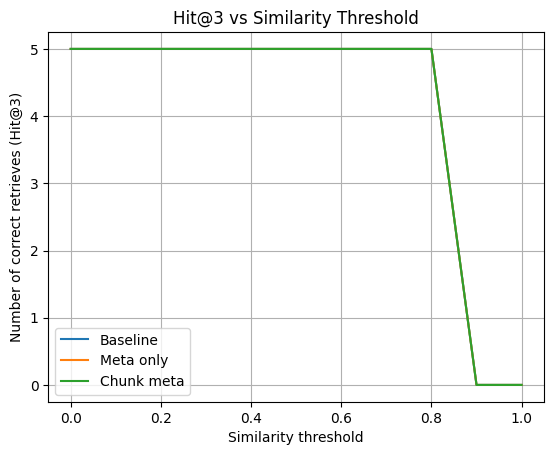

In [31]:
thresholds = [1, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0]

hits_by_retriever = hit_at_k_vs_threshold(
    retrieval_easy,
    queries_easy,
    thresholds,
    k=3)

import matplotlib.pyplot as plt

plt.figure()
for name, hits in hits_by_retriever.items():
    plt.plot(thresholds, hits, label=name)

plt.xlabel("Similarity threshold")
plt.ylabel("Number of correct retrieves (Hit@3)")
plt.title("Hit@3 vs Similarity Threshold")
plt.legend()
plt.grid(True)
plt.show()

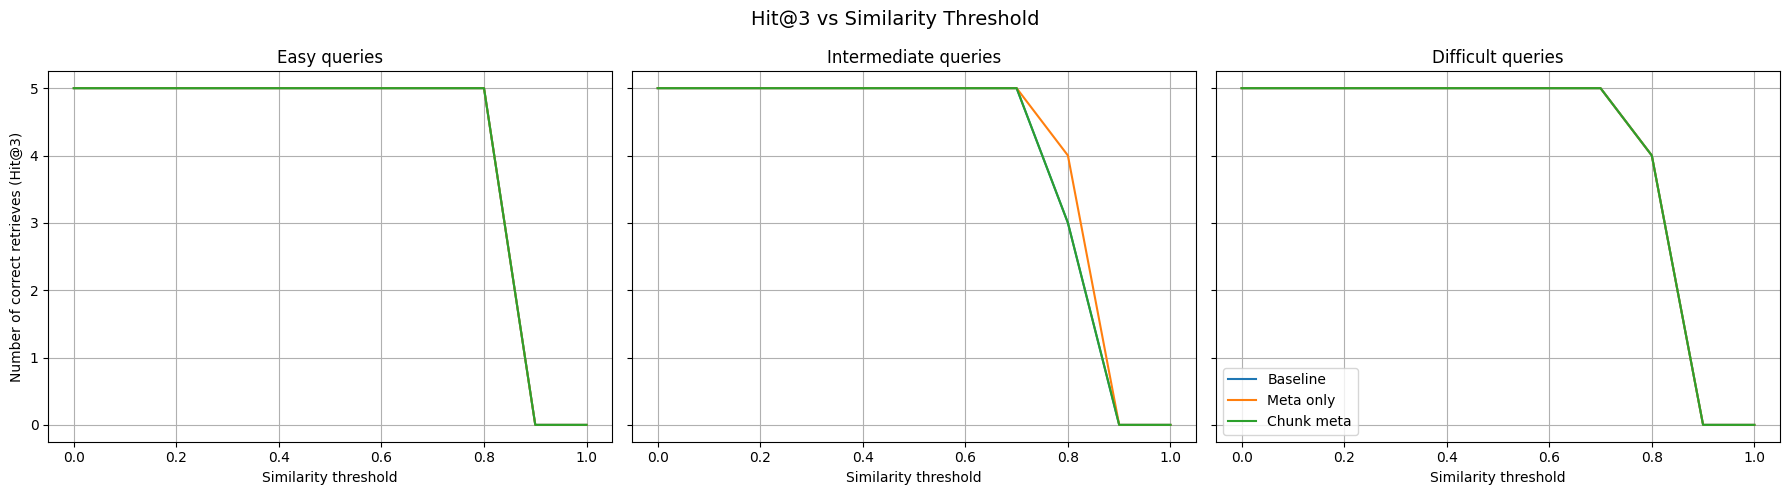

In [32]:
hits_by_retriever_easy = hit_at_k_vs_threshold(
    retrieval_easy,
    queries_easy,
    thresholds,
    k=3)

hits_by_retriever_intermediate = hit_at_k_vs_threshold(
    retrieval_intermediate,
    queries_intermediate,
    thresholds,
    k=3)

hits_by_retriever_difficult = hit_at_k_vs_threshold(
    retrieval_difficult,
    queries_difficult,
    thresholds,
    k=3)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

plots = [
    ("Easy queries", hits_by_retriever_easy),
    ("Intermediate queries", hits_by_retriever_intermediate),
    ("Difficult queries", hits_by_retriever_difficult),
]

for ax, (title, hits_dict) in zip(axes, plots):
    for name, hits in hits_dict.items():
        ax.plot(thresholds, hits, label=name)

    ax.set_title(title)
    ax.set_xlabel("Similarity threshold")
    ax.grid(True)

axes[0].set_ylabel("Number of correct retrieves (Hit@3)")

# Llegendària comuna
axes[-1].legend(loc="best")

plt.suptitle("Hit@3 vs Similarity Threshold", fontsize=14)
plt.tight_layout()
plt.show()
